# Machine Learning Based Malaria Outbreak Prediction Model

## Project Overview

This notebook develops a **machine learning-based malaria outbreak prediction model** using a RandomForestClassifier and a clean, production-style scikit-learn Pipeline.

**Key steps:**
1. Imports & Setup
2. Load Dataset
3. Automatic Target Creation (outbreak = RATE_PER_1000_NL > 50)
4. Exploratory Data Analysis (EDA)
5. Feature Engineering & Preprocessing
6. Model Training (RandomForestClassifier)
7. Model Evaluation
8. Save Trained Model
9. Automatic Prediction Example

## Imports & Setup

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.utils import class_weight
import joblib

pd.set_option("display.max_columns", 50)
sns.set(style="whitegrid")

DATA_PATH = "malaria_cases.csv"
OUTPUT_DIR = "outputs"
MODEL_PATH = os.path.join(OUTPUT_DIR, "malaria_outbreak_random_forest.joblib")
os.makedirs(OUTPUT_DIR, exist_ok=True)

RANDOM_STATE = 42
TARGET_COL = "outbreak"
THRESHOLD_RATE = 50

## Load Dataset

In [3]:
if not os.path.isfile(DATA_PATH):
    raise FileNotFoundError(f"Dataset not found at '{DATA_PATH}'.")

df = pd.read_csv(DATA_PATH)
print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Loaded: 2710 rows, 14 columns


,IND_ID,IND_CODE,IND_UUID,IND_PER_CODE,DIM_TIME,DIM_TIME_TYPE,DIM_GEO_CODE_M49,DIM_GEO_CODE_TYPE,DIM_PUBLISH_STATE_CODE,IND_NAME,GEO_NAME_SHORT,RATE_PER_1000_N,RATE_PER_1000_NL,RATE_PER_1000_NU
0,442CEA8MALARIA_EST_INCIDENCE,MALARIA_EST_INCIDENCE,442CEA8,MALARIA_EST_INCIDENCE,2001,YEAR,364,COUNTRY,PUBLISHED,Malaria cases,Iran (Islamic Republic of),28.028820,28.028820,28.028820
1,442CEA8MALARIA_EST_INCIDENCE,MALARIA_EST_INCIDENCE,442CEA8,MALARIA_EST_INCIDENCE,2001,YEAR,368,COUNTRY,PUBLISHED,Malaria cases,Iraq,0.386175,0.386175,0.386175
2,442CEA8MALARIA_EST_INCIDENCE,MALARIA_EST_INCIDENCE,442CEA8,MALARIA_EST_INCIDENCE,2001,YEAR,384,COUNTRY,PUBLISHED,Malaria cases,Côte d'Ivoire,502.600348,402.149343,621.624666
3,442CEA8MALARIA_EST_INCIDENCE,MALARIA_EST_INCIDENCE,442CEA8,MALARIA_EST_INCIDENCE,2001,YEAR,404,COUNTRY,PUBLISHED,Malaria cases,Kenya,245.449643,195.614445,303.733246
4,442CEA8MALARIA_EST_INCIDENCE,MALARIA_EST_INCIDENCE,442CEA8,MALARIA_EST_INCIDENCE,2001,YEAR,408,COUNTRY,PUBLISHED,Malaria cases,Democratic People's Republic of Korea,12.418067,12.418067,12.418067


In [ ]:
drop_cols = [
    "IND_ID",
    "IND_CODE",
    "IND_UUID",
    "IND_NAME"
]

df = df.drop(columns=drop_cols, errors="ignore")

print("Remaining columns after cleaning:")
print(df.columns.tolist())

# Create outbreak target column immediately after loading and cleaning dataset
if "RATE_PER_1000_NL" not in df.columns:
    raise ValueError("Column RATE_PER_1000_NL not found.")
df[TARGET_COL] = (df["RATE_PER_1000_NL"] > THRESHOLD_RATE).astype(int)

Remaining columns:
['IND_PER_CODE', 'DIM_TIME', 'DIM_TIME_TYPE', 'DIM_GEO_CODE_M49', 'DIM_GEO_CODE_TYPE', 'DIM_PUBLISH_STATE_CODE', 'GEO_NAME_SHORT', 'RATE_PER_1000_N', 'RATE_PER_1000_NL', 'RATE_PER_1000_NU']


In [ ]:

# Create X (features) and y (target)
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())
print("\nTarget distribution (normalized):")
print(y.value_counts(normalize=True))

KeyError: "['outbreak'] not found in axis"

In [ ]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['DIM_TIME', 'DIM_GEO_CODE_M49', 'RATE_PER_1000_N', 'RATE_PER_1000_NL', 'RATE_PER_1000_NU']
Categorical features: ['IND_PER_CODE', 'DIM_TIME_TYPE', 'DIM_GEO_CODE_TYPE', 'DIM_PUBLISH_STATE_CODE', 'GEO_NAME_SHORT']


C:\Users\allan\AppData\Local\Temp\ipykernel_3444\1263164068.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


## Exploratory Data Analysis (EDA)

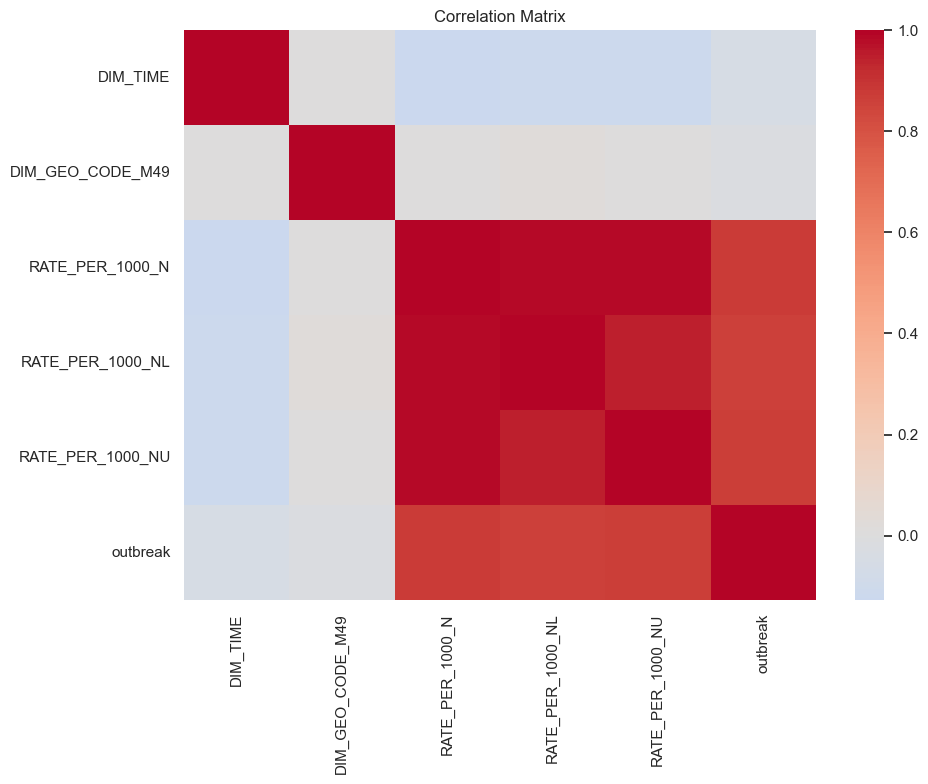

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if len(numeric_cols) > 1:
    plt.figure(figsize=(10, 8))
    sns.heatmap(df[numeric_cols].corr(), annot=False, cmap="coolwarm", center=0)
    plt.title("Correlation Matrix")
    plt.tight_layout()
    plt.show()

## Feature Engineering & Preprocessing

Build transformers for numeric and categorical features:
- Numeric: Median imputation → StandardScaler
- Categorical: Mode imputation → OneHotEncoder

In [ ]:
# Define preprocessing pipelines for numeric and categorical features
# Numeric: Impute with median + StandardScaler
# Categorical: Impute with most_frequent + OneHotEncoder

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "string"]).columns.tolist()
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

Numeric: ['DIM_TIME', 'DIM_GEO_CODE_M49', 'RATE_PER_1000_N', 'RATE_PER_1000_NL', 'RATE_PER_1000_NU']
Categorical: ['IND_PER_CODE', 'DIM_TIME_TYPE', 'DIM_GEO_CODE_TYPE', 'DIM_PUBLISH_STATE_CODE', 'GEO_NAME_SHORT']


## Model Training & Evaluation

Train a RandomForestClassifier using stratified train-test split with balanced class weights, then evaluate performance.

In [ ]:
# Split data into training (70%) and test (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Define class weights to handle potential class imbalance
classes = np.unique(y_train)
cw = class_weight.compute_class_weight("balanced", classes=classes, y=y_train)
class_weights = dict(zip(classes, cw))

# Create full ML pipeline: preprocessing → RandomForestClassifier
rf_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300, 
        random_state=RANDOM_STATE, 
        class_weight=class_weights, 
        n_jobs=-1
    )),
])

# Train the pipeline on the training data
rf_pipeline.fit(X_train, y_train)
print("\n✓ Model training complete.")

Train: 1897, Test: 813
Training complete.


## Model Evaluation

In [ ]:
y_pred = rf_pipeline.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1-score:", f1_score(y_test, y_pred, zero_division=0))
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       556
           1       1.00      1.00      1.00       257

    accuracy                           1.00       813
   macro avg       1.00      1.00      1.00       813
weighted avg       1.00      1.00      1.00       813



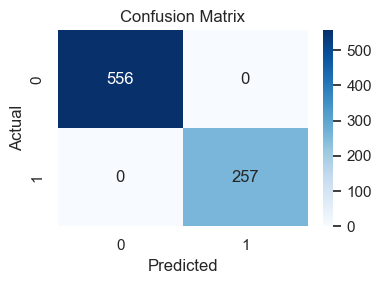

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## Save Trained Model

In [ ]:
bundle = {"pipeline": rf_pipeline, "feature_names": X.columns.tolist()}
joblib.dump(bundle, MODEL_PATH)
print(f"Saved to {MODEL_PATH}")

Saved to outputs\malaria_outbreak_random_forest.joblib


## Automatic Prediction Example

Load pipeline and run **pipeline.predict()** on an example row (no manual scaler).

In [ ]:
loaded = joblib.load(MODEL_PATH)
pipe = loaded["pipeline"]
feature_names = loaded["feature_names"]

example_sample = X.iloc[[0]].copy()
pred = pipe.predict(example_sample)[0]
print("Predicted outbreak risk:", int(pred), "(0 = no outbreak, 1 = outbreak)")

Predicted outbreak risk: 0 (0 = no outbreak, 1 = outbreak)
